In [1]:
# Cargamos la librerías que vamos a necesitar para poder abordar el problema
import numpy as np
import pandas as pd
import torch
from torch import nn
import time
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

/home/alumnos/davidase/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/alumnos/davidase/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/alumnos/davidase/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def modelo3D(t, z, λ, K, β, γ, b, δ):
  x, y, v = z

  # Sistema dinámico simplificado (Tian 2011: βv = βy = 0)
  dx = λ * x * (1 - (x + y) / K) - β * x * v
  dy = β * x * v - γ * y
  dv = -β * x * v + b * γ * y - δ * v

  return [dx, dy, dv]

In [3]:
def model_adim(t, z, r, a, b, c):
    x, y, v = z
    dx = r * x * (1 - x - y) - a * x * v
    dy = a * x * v - y
    dv = b * y - a * x * v - c * v
    return [dx, dy, dv]

# Estimar: "b" y "a"

## Parámetros del modelo y condiciones iniciales

In [4]:
# Parámetros adimensionales del modelo de Tian (adimensionalización con γ=1, K=1)
c = 0.2     # Tasa de eliminación del virus
r = 0.36

b_true = 9.0
a_true = 0.11

# Condiciones iniciales
x0 = 0.5    # Células sanas iniciales
y0 = 0.5    # Células infectadas iniciales
v0 = 1.5    # Carga viral inicial

# Tiempo máximo de simulación
TAU_MAX = 200.0

In [5]:
torch.manual_seed(42)
np.random.seed(42)

# Número de puntos de observación
N_OBS = 100

# Tiempos de observación distribuidos uniformemente en [0, TAU_MAX]
t_obs_np = np.linspace(0, TAU_MAX, N_OBS)

# Solución de referencia con b_true
sol_data = solve_ivp(
    model_adim,
    [0, TAU_MAX],
    [x0, y0, v0],
    args=(r, a_true, b_true, c),
    t_eval=t_obs_np,
    method='LSODA',
    rtol=1e-8, atol=1e-10
)

# Nivel de ruido relativo
noise_level = 0.0

x_clean = sol_data.y[0]
y_clean = sol_data.y[1]
v_clean = sol_data.y[2]

x_noisy = x_clean + noise_level * np.std(x_clean) * np.random.randn(N_OBS)
y_noisy = y_clean + noise_level * np.std(y_clean) * np.random.randn(N_OBS)
v_noisy = v_clean + noise_level * np.std(v_clean) * np.random.randn(N_OBS)

# Convertimos a tensores de PyTorch
t_data   = torch.tensor(t_obs_np,  dtype=torch.float32).view(-1, 1)
x_data   = torch.tensor(x_noisy,   dtype=torch.float32).view(-1, 1)
y_data   = torch.tensor(y_noisy,   dtype=torch.float32).view(-1, 1)
v_data   = torch.tensor(v_noisy,   dtype=torch.float32).view(-1, 1)

print(f"Datos generados: {N_OBS} observaciones en t ∈ [0, {TAU_MAX}]")
print(f"Valor verdadero de b: {b_true}")
print(f"Valor verdadero de a: {a_true}")

Datos generados: 100 observaciones en t ∈ [0, 200.0]
Valor verdadero de b: 9.0
Valor verdadero de a: 0.11


In [6]:
class VIRO_NN(nn.Module):
    """Red neuronal para el problema inverso de viroterapia.

    Aproxima la solución (x(t), y(t), v(t)) del sistema adimensionalizado
    de Tian mientras co-estima el parámetro b (tamaño de explosión viral).
    """

    def __init__(self, N_HIDDEN, N_LAYERS, x0=0.5, y0=0.5, v0=1.5):
        super().__init__()
        activation = nn.SiLU  # Tanh: gradientes suaves, adecuada para PINNs

        self.x0 = x0
        self.y0 = y0
        self.v0 = v0

        N_INPUT  = 1
        N_OUTPUT = 3

        # Capa de entrada
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )
        # Capas ocultas
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation())
            for _ in range(N_LAYERS - 1)
        ])
        # Capa de salida
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, t):
        # Normalización al intervalo [0, 1]
        tau = t / TAU_MAX

        out = self.fcs(tau)
        out = self.fch(out)
        out = self.fce(out)

        # Ansatz: garantiza condiciones iniciales exactas
        x = self.x0 + tau * out[:, 0:1]
        y = self.y0 + tau * out[:, 1:2]
        v = self.v0 + tau * out[:, 2:3]

        return torch.cat([x, y, v], dim=1)

## Generación de datos sintéticos de entrenamiento

Simulamos el sistema con el valor verdadero `b_true` para obtener observaciones
a las que añadimos ruido gaussiano. Estas observaciones son los "datos clínicos"
que la PINN usará para estimar `b`.

Iniciando entrenamiento:
  a_init = 0.2000 | a_true = 0.11
  b_init = 1.0000 | b_true = 9.0
Épocas: 30001 | Puntos físicos: 1500 | Observaciones: 100

Época      0 | Loss: 1.47e+02 | a_est = 0.2010 | b_est = 0.9990 | t: 0.0s


/home/alumnos/davidase/.local/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


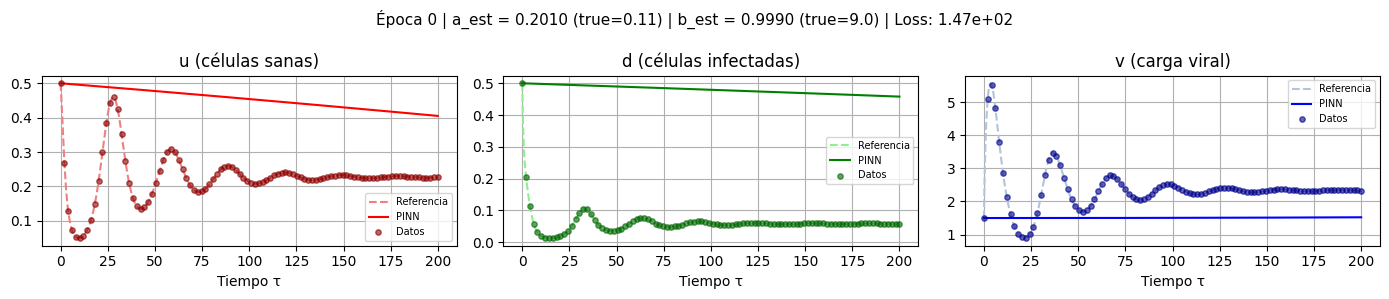

Época   5000 | Loss: 4.31e-02 | a_est = -0.0065 | b_est = 5.3589 | t: 118.5s


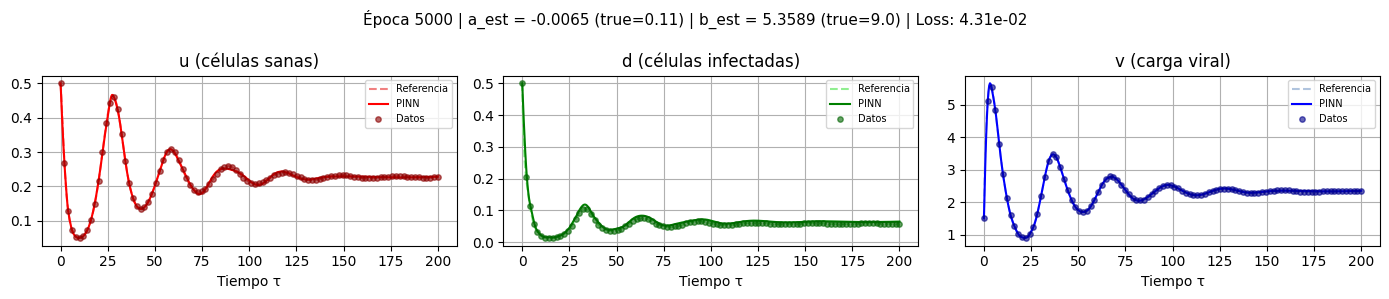

Época  10000 | Loss: 7.26e-03 | a_est = 0.0913 | b_est = 8.1472 | t: 243.4s


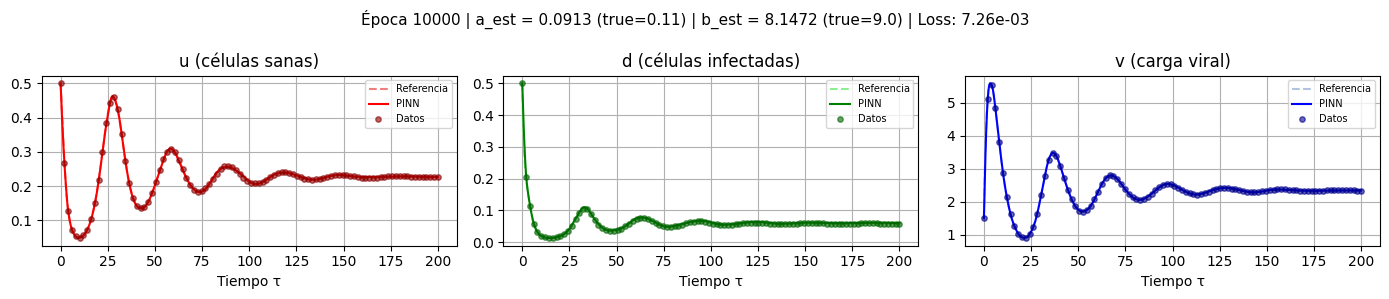

Época  15000 | Loss: 4.01e-03 | a_est = 0.1032 | b_est = 8.6125 | t: 364.7s


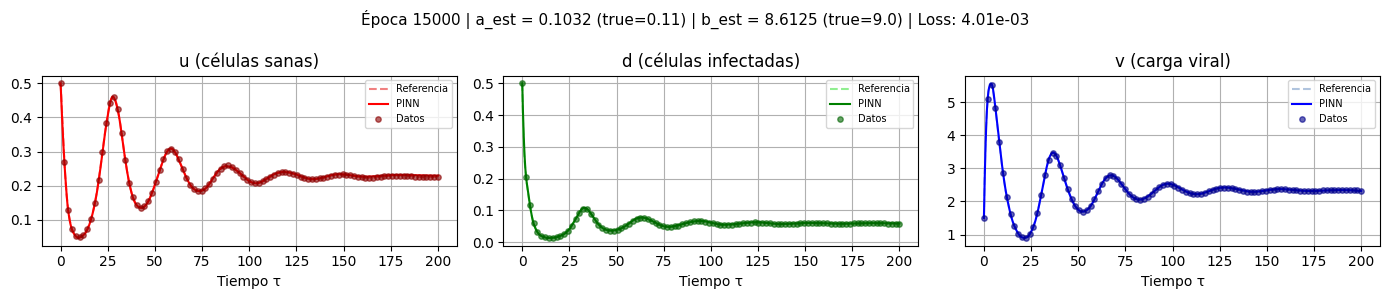

Época  20000 | Loss: 1.16e-03 | a_est = 0.1046 | b_est = 8.7142 | t: 484.3s


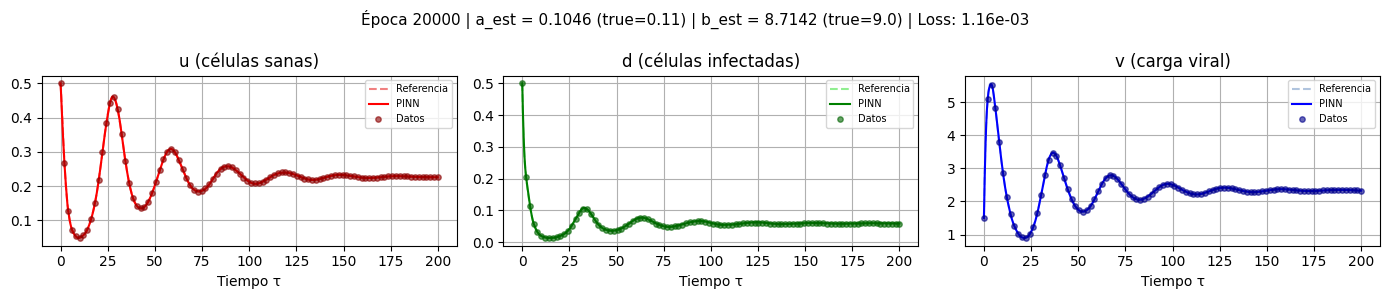

Época  25000 | Loss: 5.99e-04 | a_est = 0.1065 | b_est = 8.8149 | t: 606.1s


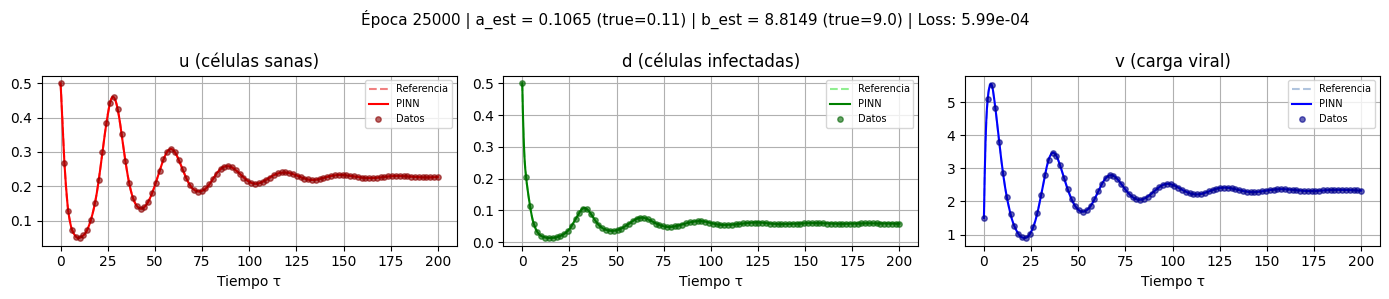

Época  30000 | Loss: 4.09e-04 | a_est = 0.1074 | b_est = 8.8607 | t: 729.5s


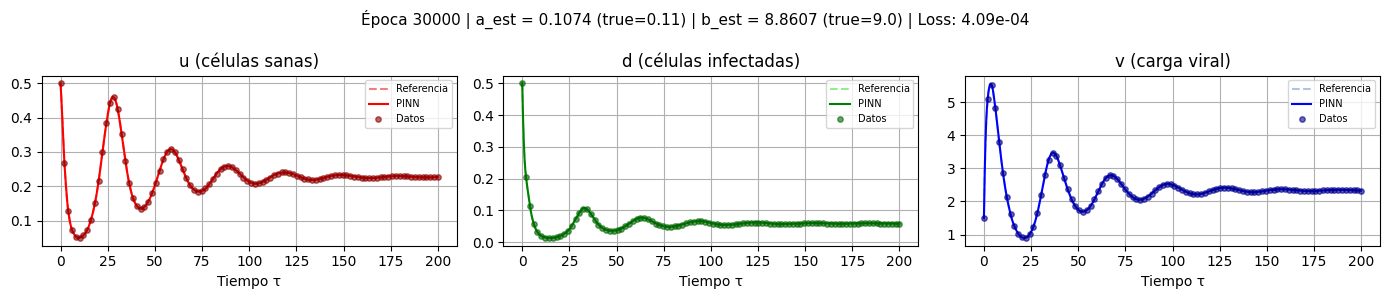


Entrenamiento finalizado en 729.7s
a estimado:      0.1074 | a verdadero: 0.11
b estimado:      8.8607 | b verdadero: 9.0
Error rel. a:    2.36%
Error rel. b:    1.55%


In [7]:
torch.manual_seed(123)

# Instanciamos la red neuronal
pinn = VIRO_NN(N_HIDDEN=164, N_LAYERS=4)

# Puntos de colocación física (donde se evalúan las EDOs)
N_PHYS = 1500
t_physic = torch.linspace(0, TAU_MAX, N_PHYS).view(-1, 1).requires_grad_(True)
t_test   = torch.linspace(0, TAU_MAX, 500).view(-1, 1)   # más resolución para el plot

a_param = nn.Parameter(torch.tensor([0.2], requires_grad=True))
b_param = nn.Parameter(torch.tensor([1.0], requires_grad=True))

a_vals = []  # historial del valor de a
b_vals = []  # historial del valor de b
losses = []  # historial de la pérdida total

# Ambos parámetros se añaden al optimizador junto con los pesos de la red
optimiser = torch.optim.Adam(list(pinn.parameters()) + [a_param, b_param], lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=1000, min_lr=1e-5
)

# Peso de la pérdida de datos frente a la física
lambda_data = 1e2
lambda_phys = 1

N_EPOCHS    = 30001
PLOT_EVERY  = 5000

print(f"Iniciando entrenamiento:")
print(f"  a_init = {a_param.item():.4f} | a_true = {a_true}")
print(f"  b_init = {b_param.item():.4f} | b_true = {b_true}")
print(f"Épocas: {N_EPOCHS} | Puntos físicos: {N_PHYS} | Observaciones: {N_OBS}\n")

t0 = time.time()

t_test_np = t_test.detach().numpy().flatten()
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r, a_true, b_true, c), t_eval=t_test_np, method='LSODA'
)

for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    pred_phys = pinn(t_physic)
    xp = pred_phys[:, 0:1]
    yp = pred_phys[:, 1:2]
    vp = pred_phys[:, 2:3]

    ones = torch.ones_like(xp)
    dxdt = torch.autograd.grad(xp, t_physic, ones, create_graph=True)[0]
    dydt = torch.autograd.grad(yp, t_physic, ones, create_graph=True)[0]
    dvdt = torch.autograd.grad(vp, t_physic, ones, create_graph=True)[0]

    res_x = dxdt - (r * xp * (1 - xp - yp) - a_param * xp * vp)
    res_y = dydt - (a_param * xp * vp - yp)
    res_v = dvdt - (b_param * yp - a_param * xp * vp - c * vp)

    loss_phys = torch.mean(res_x**2 + res_y**2 + res_v**2)

    pred_data = pinn(t_data)
    loss_data = torch.mean(
        (pred_data[:, 0:1] - x_data)**2 +
        (pred_data[:, 1:2] - y_data)**2 +
        (pred_data[:, 2:3] - v_data)**2
    )

    loss = lambda_phys * loss_phys + lambda_data * loss_data
    loss.backward()
    optimiser.step()
    scheduler.step(loss)

    a_vals.append(a_param.item())
    b_vals.append(b_param.item())
    losses.append(loss.item())

    if epoch % PLOT_EVERY == 0:
        elapsed = time.time() - t0
        print(f"Época {epoch:>6} | Loss: {loss.item():.2e} "
              f"| a_est = {a_param.item():.4f} | b_est = {b_param.item():.4f} "
              f"| t: {elapsed:.1f}s")

        with torch.no_grad():
            u = pinn(t_test)
            x_pred = u[:, 0].numpy()
            y_pred = u[:, 1].numpy()
            v_pred = u[:, 2].numpy()

        t_data_np = t_data.detach().numpy().flatten()

        fig, axes = plt.subplots(1, 3, figsize=(14, 3))

        axes[0].plot(t_test_np, sol_ref.y[0], '--', color='lightcoral',    lw=1.5, label='Referencia')
        axes[0].plot(t_test_np, x_pred,        '-',  color='red',            lw=1.5, label='PINN')
        axes[0].scatter(t_data_np, x_data.numpy().flatten(),
                        s=15, color='darkred', alpha=0.6, zorder=5, label='Datos')
        axes[0].set_title('u (células sanas)')

        axes[1].plot(t_test_np, sol_ref.y[1], '--', color='lightgreen',    lw=1.5, label='Referencia')
        axes[1].plot(t_test_np, y_pred,        '-',  color='green',          lw=1.5, label='PINN')
        axes[1].scatter(t_data_np, y_data.numpy().flatten(),
                        s=15, color='darkgreen', alpha=0.6, zorder=5, label='Datos')
        axes[1].set_title('d (células infectadas)')

        axes[2].plot(t_test_np, sol_ref.y[2], '--', color='lightsteelblue', lw=1.5, label='Referencia')
        axes[2].plot(t_test_np, v_pred,        '-',  color='blue',            lw=1.5, label='PINN')
        axes[2].scatter(t_data_np, v_data.numpy().flatten(),
                        s=15, color='darkblue', alpha=0.6, zorder=5, label='Datos')
        axes[2].set_title('v (carga viral)')

        for ax in axes:
            ax.set_xlabel('Tiempo τ')
            ax.legend(fontsize=7)
            ax.grid(True)

        plt.suptitle(
            f'Época {epoch} | a_est = {a_param.item():.4f} (true={a_true}) | '
            f'b_est = {b_param.item():.4f} (true={b_true}) | Loss: {loss.item():.2e}',
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

print(f"\nEntrenamiento finalizado en {time.time()-t0:.1f}s")
print(f"a estimado:      {a_param.item():.4f} | a verdadero: {a_true}")
print(f"b estimado:      {b_param.item():.4f} | b verdadero: {b_true}")
print(f"Error rel. a:    {abs(a_param.item() - a_true) / abs(a_true) * 100:.2f}%")
print(f"Error rel. b:    {abs(b_param.item() - b_true) / abs(b_true) * 100:.2f}%")

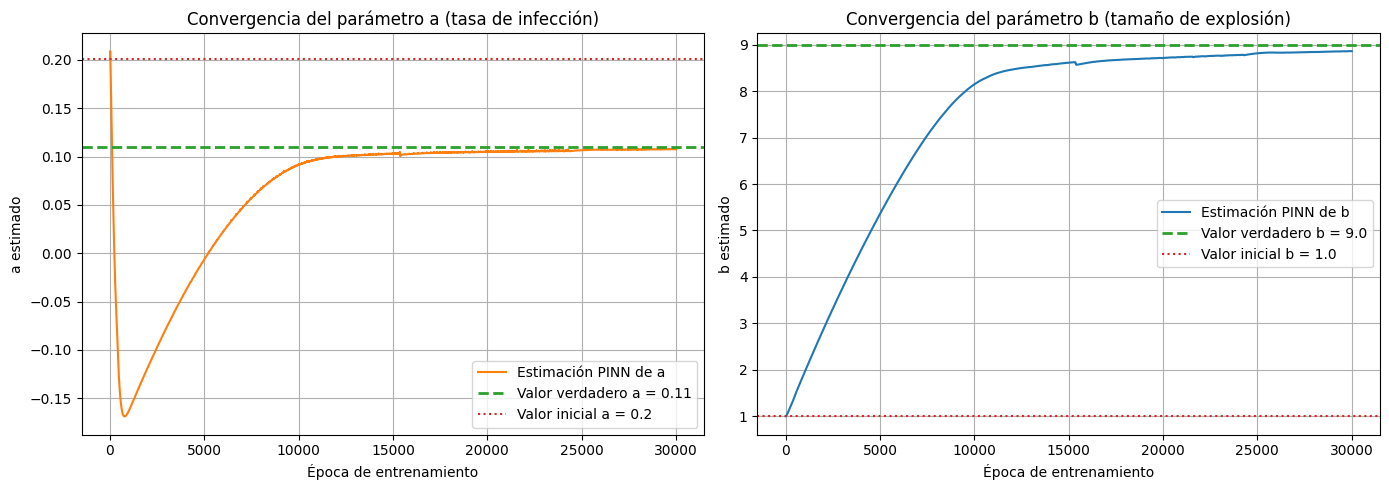


Resumen de la estimación:
--- Parámetro a ---
  Valor inicial:   a = 0.2010
  Valor final:     a = 0.1074
  Valor verdadero: a = 0.11
  Error relativo:  2.36%

--- Parámetro b ---
  Valor inicial:   b = 0.9990
  Valor final:     b = 8.8607
  Valor verdadero: b = 9.0
  Error relativo:  1.55%


In [8]:
# Creamos una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(a_vals, label='Estimación PINN de a', color='tab:orange', linewidth=1.5)
axes[0].axhline(a_true, color='tab:green', linestyle='--', linewidth=2,
            label=f'Valor verdadero a = {a_true}')
axes[0].axhline(a_vals[0], color='tab:red', linestyle=':', linewidth=1.5,
            label=f'Valor inicial a = {a_vals[0]:.1f}')
axes[0].set_xlabel('Época de entrenamiento')
axes[0].set_ylabel('a estimado')
axes[0].set_title('Convergencia del parámetro a (tasa de infección)')
axes[0].legend()
axes[0].grid(True)


axes[1].plot(b_vals, label='Estimación PINN de b', color='tab:blue', linewidth=1.5)
axes[1].axhline(b_true, color='tab:green', linestyle='--', linewidth=2,
            label=f'Valor verdadero b = {b_true}')
axes[1].axhline(b_vals[0], color='tab:red', linestyle=':', linewidth=1.5,
            label=f'Valor inicial b = {b_vals[0]:.1f}')
axes[1].set_xlabel('Época de entrenamiento')
axes[1].set_ylabel('b estimado')
axes[1].set_title('Convergencia del parámetro b (tamaño de explosión)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nResumen de la estimación:")
print("--- Parámetro a ---")
print(f"  Valor inicial:   a = {a_vals[0]:.4f}")
print(f"  Valor final:     a = {a_vals[-1]:.4f}")
print(f"  Valor verdadero: a = {a_true}")
print(f"  Error relativo:  {abs(a_vals[-1] - a_true) / a_true * 100:.2f}%\n")

print("--- Parámetro b ---")
print(f"  Valor inicial:   b = {b_vals[0]:.4f}")
print(f"  Valor final:     b = {b_vals[-1]:.4f}")
print(f"  Valor verdadero: b = {b_true}")
print(f"  Error relativo:  {abs(b_vals[-1] - b_true) / b_true * 100:.2f}%")

## Estimar: "b", "a" y "r"

In [9]:
# Parámetros adimensionales del modelo de Tian (adimensionalización con γ=1, K=1)
c = 0.2     # Tasa de eliminación del virus

b_true = 9.0
a_true = 0.11
r_true = 0.36

# Condiciones iniciales
x0 = 0.5    # Células sanas iniciales
y0 = 0.5    # Células infectadas iniciales
v0 = 1.5    # Carga viral inicial

# Tiempo máximo de simulación
TAU_MAX = 200.0

Iniciando entrenamiento:
  r_init = 0.5000 | r_true = 0.36
  a_init = 0.2000 | a_true = 0.11
  b_init = 1.0000 | b_true = 9.0
Época      0 | Loss: 1.53e+04 | a_est = 0.2010 | b_est = 0.9990 | t: 0.0s


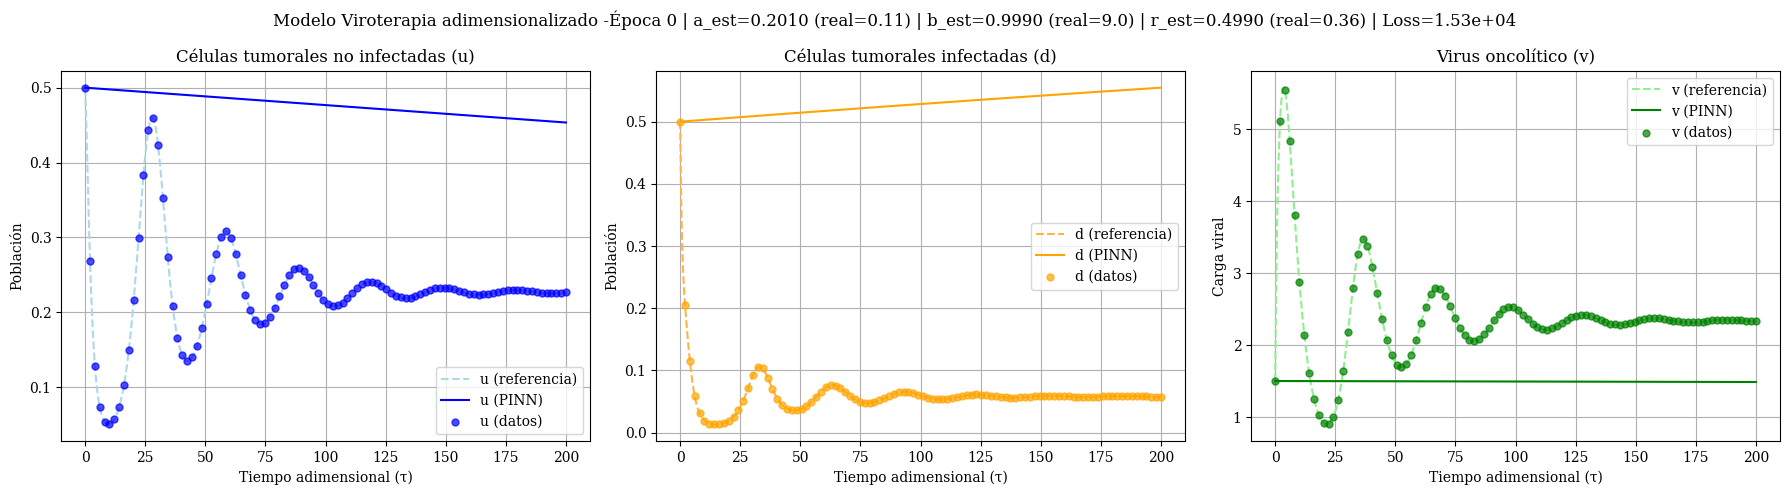

Época   5000 | Loss: 2.59e-01 | a_est = -0.1048 | b_est = 5.1720 | t: 70.2s


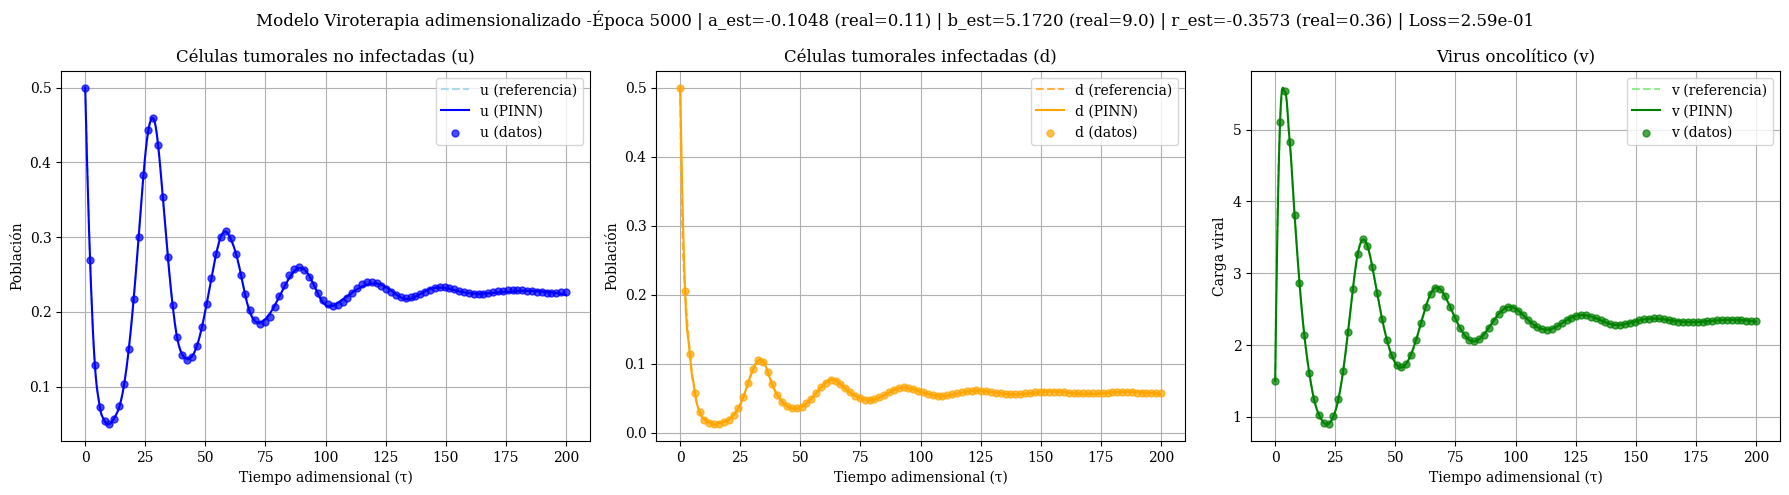

Época  10000 | Loss: 3.50e-02 | a_est = 0.0654 | b_est = 8.1228 | t: 140.8s


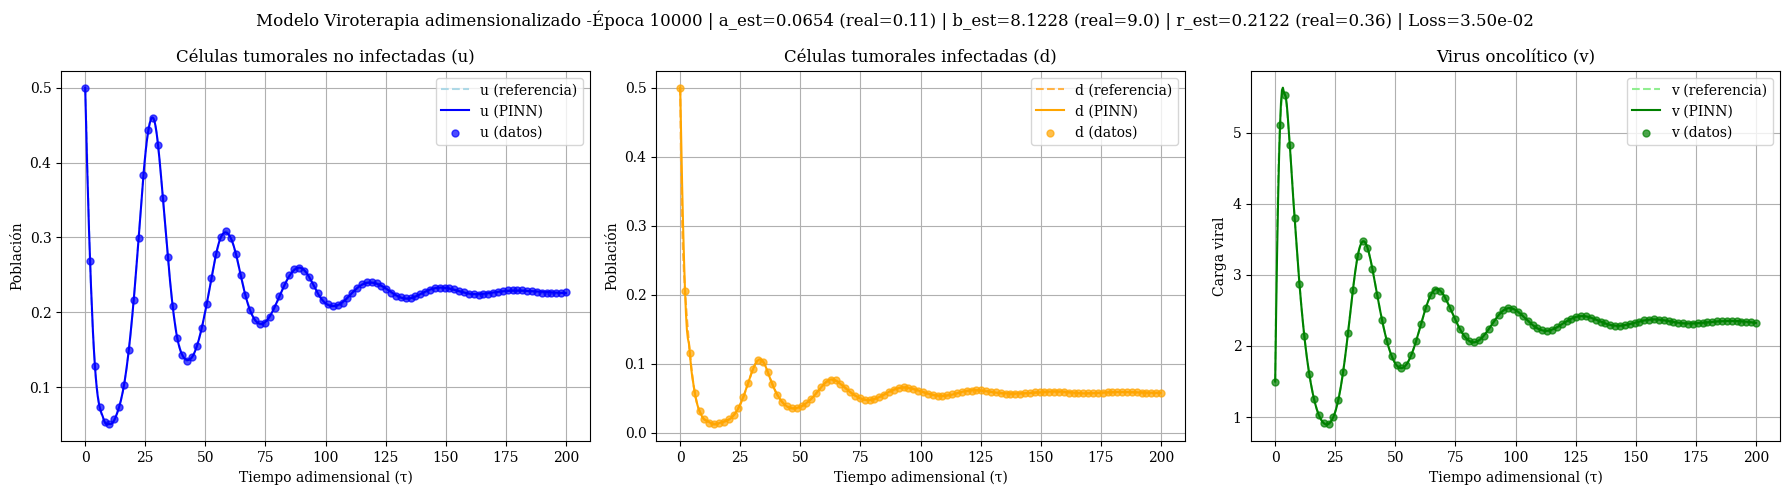

Época  15000 | Loss: 1.40e-01 | a_est = 0.0788 | b_est = 8.3595 | t: 215.7s


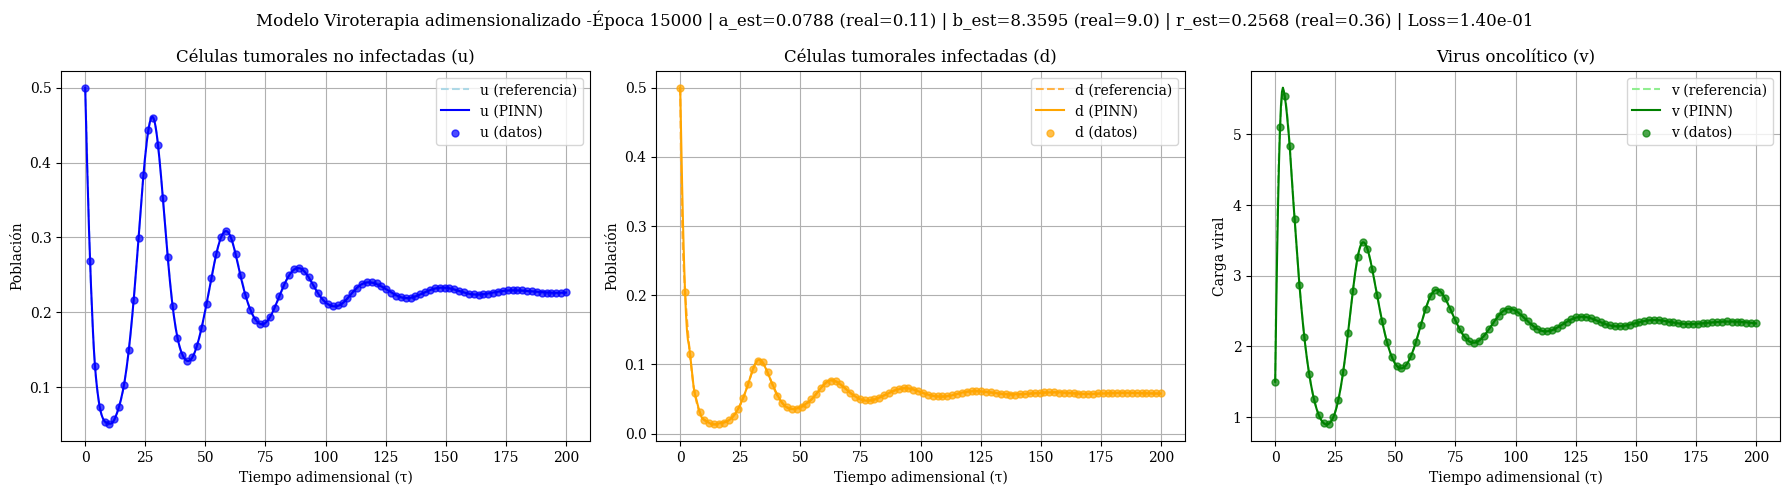

Época  20000 | Loss: 1.70e-02 | a_est = 0.0894 | b_est = 8.5730 | t: 286.0s


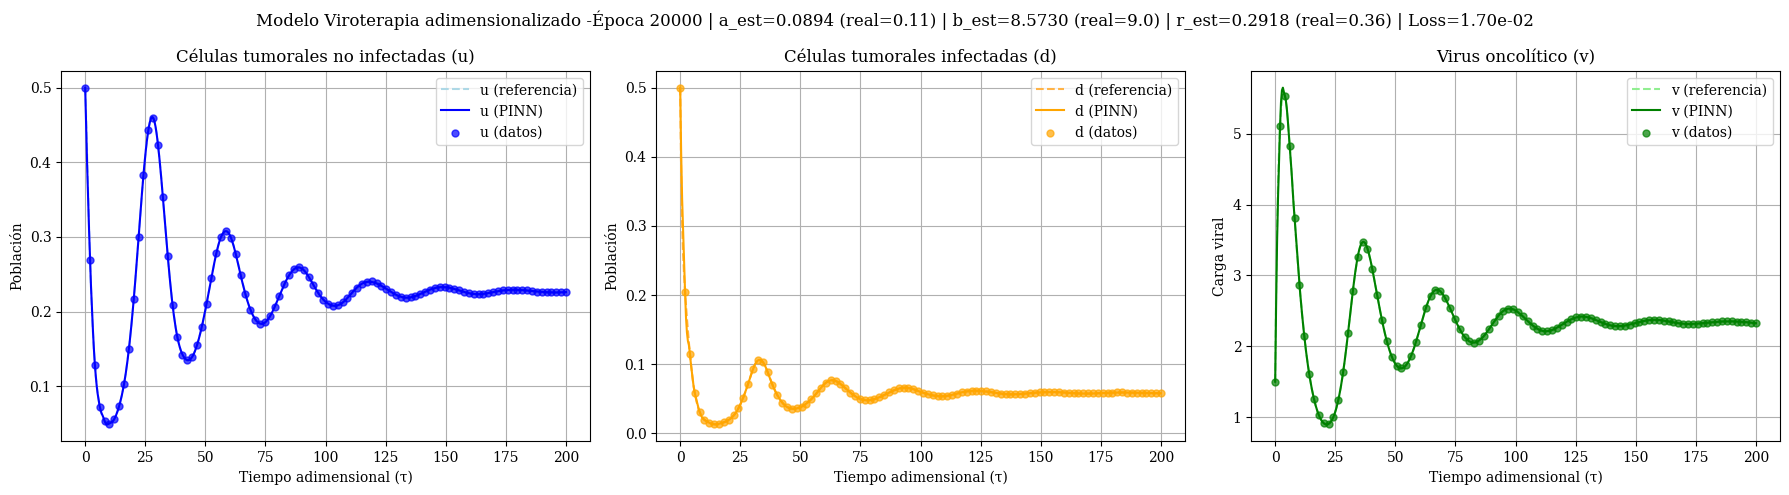

Época  25000 | Loss: 1.56e-02 | a_est = 0.0996 | b_est = 8.8096 | t: 358.2s


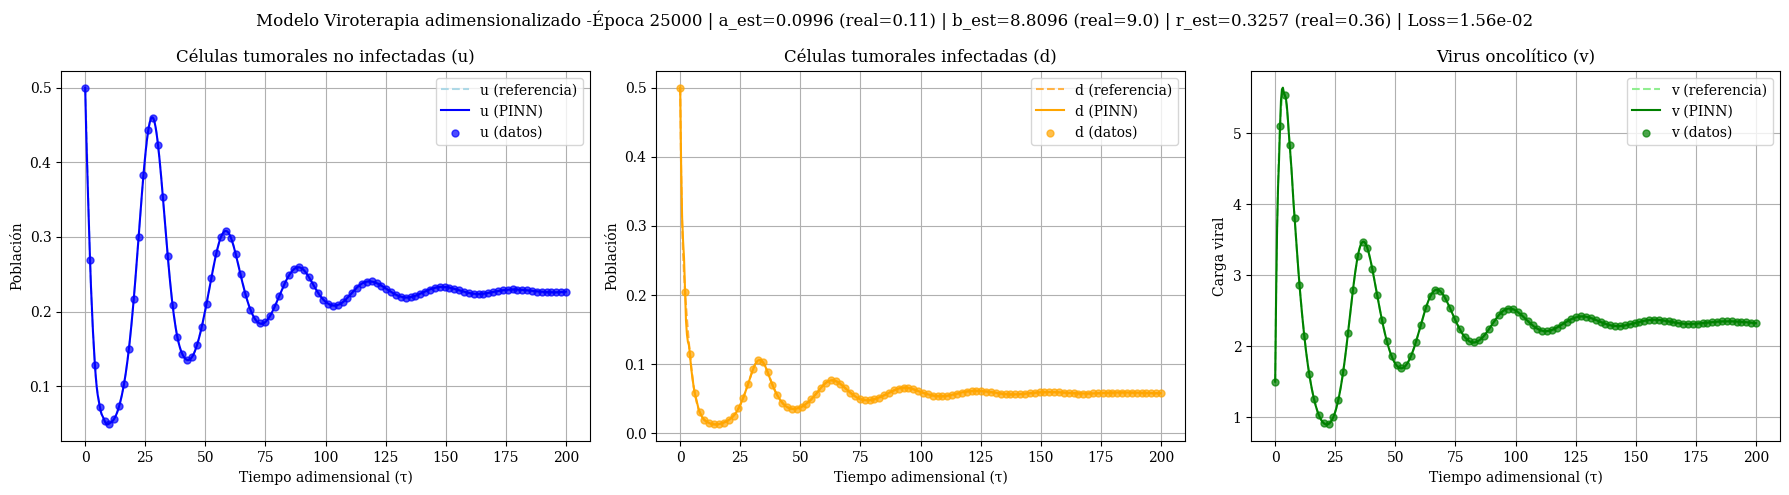

Época  30000 | Loss: 2.91e-02 | a_est = 0.1042 | b_est = 8.9143 | t: 429.6s


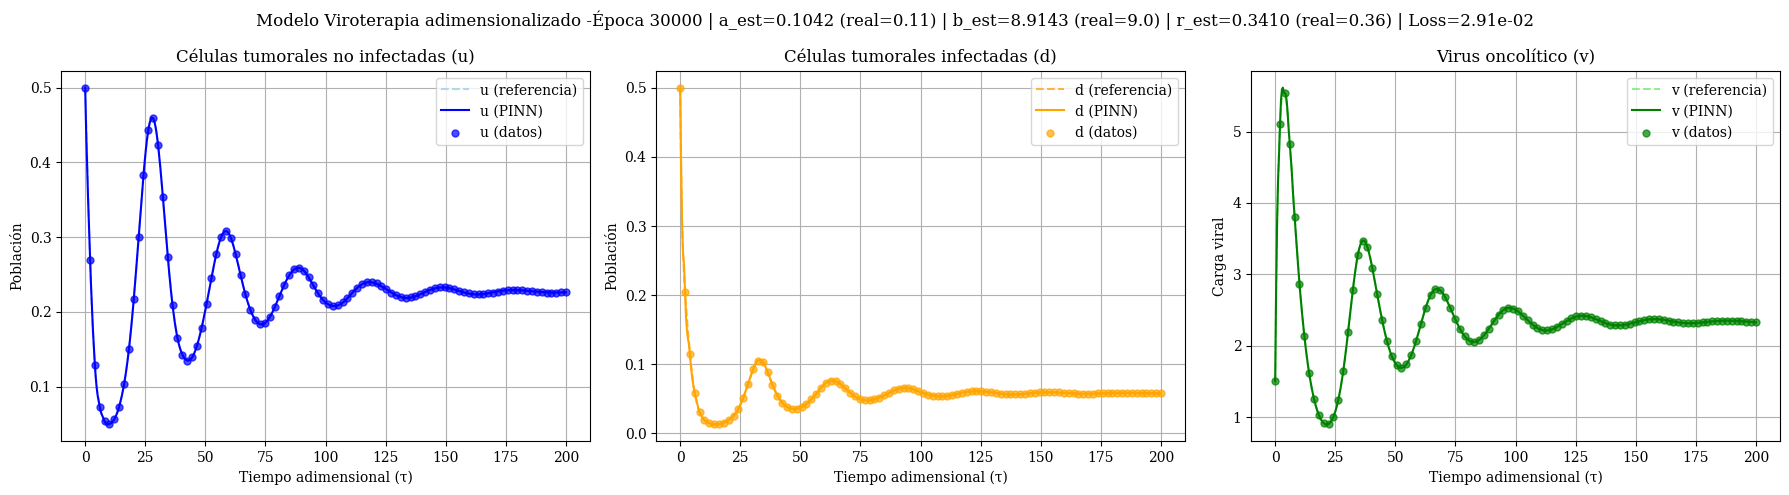

In [10]:
torch.manual_seed(123)

# Instanciamos la red neuronal
pinn = VIRO_NN(N_HIDDEN=164, N_LAYERS=5)

# Puntos de colocación física
N_PHYS = 1000
t_physic = torch.linspace(0, TAU_MAX, N_PHYS).view(-1, 1).requires_grad_(True)
t_test   = torch.linspace(0, TAU_MAX, 500).view(-1, 1)

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETROS A ESTIMAR: r, a, b
# ─────────────────────────────────────────────────────────────────────────────
r_param = nn.Parameter(torch.tensor([0.5], requires_grad=True))
a_param = nn.Parameter(torch.tensor([0.2], requires_grad=True))
b_param = nn.Parameter(torch.tensor([1.0], requires_grad=True))

r_vals = []
a_vals = []
b_vals = []
losses = []

# Los tres parámetros se añaden al optimizador
optimiser = torch.optim.Adam(list(pinn.parameters()) + [r_param, a_param, b_param], lr=1e-3)

lambda_data = 1e4
N_EPOCHS    = 30001
PLOT_EVERY  = 5000

print(f"Iniciando entrenamiento:")
print(f"  r_init = {r_param.item():.4f} | r_true = {r_true}")
print(f"  a_init = {a_param.item():.4f} | a_true = {a_true}")
print(f"  b_init = {b_param.item():.4f} | b_true = {b_true}")

t0 = time.time()

t_test_np = t_test.detach().numpy().flatten()
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r_true, a_true, b_true, c), t_eval=t_test_np, method='LSODA'
)

for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    # ── 1. PÉRDIDA FÍSICA ─────────────────────────────────────────────────
    pred_phys = pinn(t_physic)
    xp = pred_phys[:, 0:1]
    yp = pred_phys[:, 1:2]
    vp = pred_phys[:, 2:3]

    ones = torch.ones_like(xp)
    dxdt = torch.autograd.grad(xp, t_physic, ones, create_graph=True)[0]
    dydt = torch.autograd.grad(yp, t_physic, ones, create_graph=True)[0]
    dvdt = torch.autograd.grad(vp, t_physic, ones, create_graph=True)[0]

    # EDOs con los TRES parámetros a estimar (c se mantiene constante)
    res_x = dxdt - (r_param * xp * (1 - xp - yp) - a_param * xp * vp)
    res_y = dydt - (a_param * xp * vp - yp)
    res_v = dvdt - (b_param * yp - a_param * xp * vp - c * vp)

    loss_phys = torch.mean(res_x**2 + res_y**2 + res_v**2)

    # ── 2. PÉRDIDA DE DATOS ───────────────────────────────────────────────
    pred_data = pinn(t_data)
    loss_data = torch.mean(
        (pred_data[:, 0:1] - x_data)**2 +
        (pred_data[:, 1:2] - y_data)**2 +
        (pred_data[:, 2:3] - v_data)**2
    )

    # ── 3. PÉRDIDA TOTAL + BACKPROP ───────────────────────────────────────
    loss = loss_phys + lambda_data * loss_data
    loss.backward()
    optimiser.step()

    r_vals.append(r_param.item())
    a_vals.append(a_param.item())
    b_vals.append(b_param.item())
    losses.append(loss.item())

    # ── 4. LOG + PLOT INTERMEDIO ──────────────────────────────────────────
    if epoch % PLOT_EVERY == 0:
        elapsed = time.time() - t0
        print(f"Época {epoch:>6} | Loss: {loss.item():.2e} "
              f"| a_est = {a_param.item():.4f} | b_est = {b_param.item():.4f} "
              f"| t: {elapsed:.1f}s")

        # Predicción actual de la PINN (sin gradientes)
        with torch.no_grad():
            u = pinn(t_test)
            x_pred = u[:, 0].numpy()
            y_pred = u[:, 1].numpy()
            v_pred = u[:, 2].numpy()

        t_data_np = t_data.detach().numpy().flatten()

        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
        plt.rcParams["font.size"] = 10

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

        ax1.plot(t_test_np, sol_ref.y[0], '--', color='lightblue',    lw=1.5, label='u (referencia)')
        ax1.plot(t_test_np, x_pred,        '-',  color='blue',           lw=1.5, label='u (PINN)')
        ax1.scatter(t_data_np, x_data.numpy().flatten(), s=25, color='blue',   alpha=0.7, zorder=5, label='u (datos)')
        ax1.set_title('Células tumorales no infectadas (u)')
        ax1.set_xlabel('Tiempo adimensional (τ)')
        ax1.set_ylabel('Población')
        ax1.legend()
        ax1.grid(True)

        ax2.plot(t_test_np, sol_ref.y[1], '--', color='#FFB347',    lw=1.5, label='d (referencia)')
        ax2.plot(t_test_np, y_pred,        '-',  color='orange',         lw=1.5, label='d (PINN)')
        ax2.scatter(t_data_np, y_data.numpy().flatten(), s=25, color='orange', alpha=0.7, zorder=5, label='d (datos)')
        ax2.set_title('Células tumorales infectadas (d)')
        ax2.set_xlabel('Tiempo adimensional (τ)')
        ax2.set_ylabel('Población')
        ax2.legend()
        ax2.grid(True)

        ax3.plot(t_test_np, sol_ref.y[2], '--', color='lightgreen', lw=1.5, label='v (referencia)')
        ax3.plot(t_test_np, v_pred,        '-',  color='green',           lw=1.5, label='v (PINN)')
        ax3.scatter(t_data_np, v_data.numpy().flatten(), s=25, color='green',  alpha=0.7, zorder=5, label='v (datos)')
        ax3.set_title('Virus oncolítico (v)')
        ax3.set_xlabel('Tiempo adimensional (τ)')
        ax3.set_ylabel('Carga viral')
        ax3.legend()
        ax3.grid(True)

        fig.suptitle(
            'Modelo Viroterapia adimensionalizado -'
            f'Época {epoch} | '
            f'a_est={a_param.item():.4f} (real={a_true}) | '
            f'b_est={b_param.item():.4f} (real={b_true}) | '
            f'r_est={r_param.item():.4f} (real={r_true}) | '
            f'Loss={loss.item():.2e}',
            fontsize=12
        )

        plt.tight_layout()
        plt.savefig(f"inverse_epoch_{epoch}.pdf", bbox_inches="tight")
        plt.show()

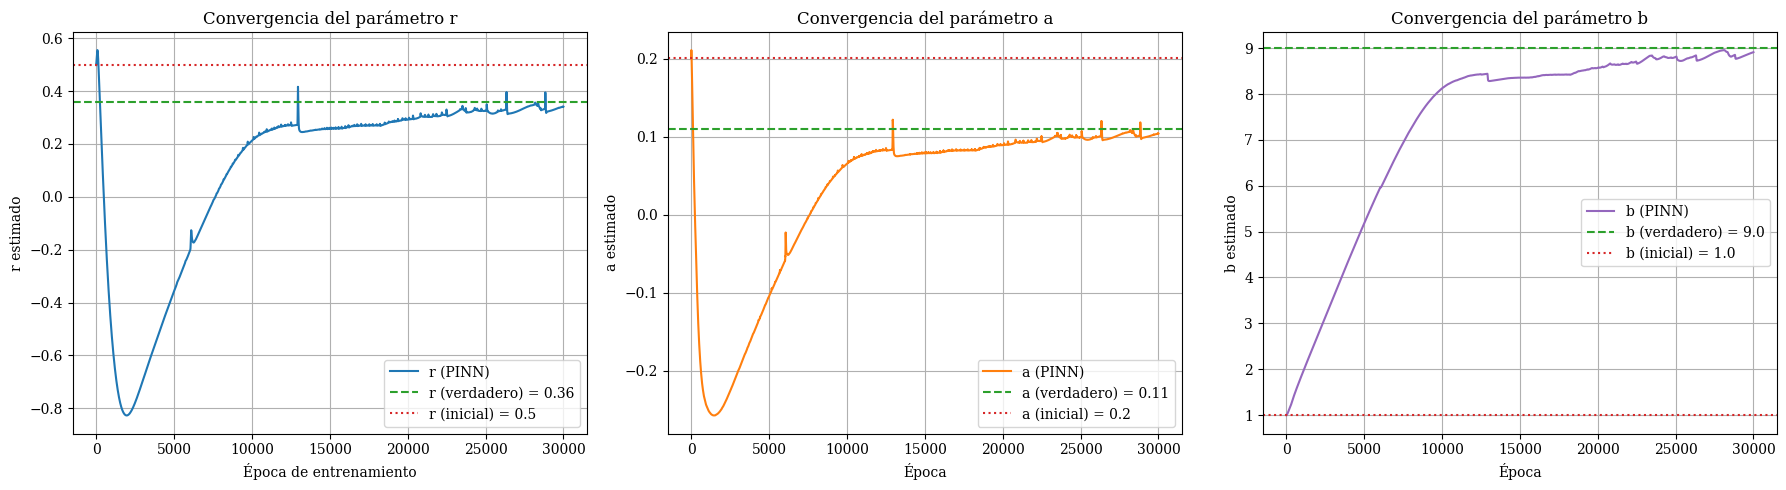


 Parámetro r (Tasa de crecimiento celular)
  Valor inicial:   r = 0.4990
  Valor final:     r = 0.3410
  Valor verdadero: r = 0.36
  Error relativo:  5.27%

 Parámetro a (Tasa de infección)
  Valor inicial:   a = 0.2010
  Valor final:     a = 0.1042
  Valor verdadero: a = 0.11
  Error relativo:  5.31%

 Parámetro b (Tamaño de explosión viral)
  Valor inicial:   b = 0.9990
  Valor final:     b = 8.9143
  Valor verdadero: b = 9.0
  Error relativo:  0.95%



In [11]:
# Creamos una figura con 1 fila y 3 columnas
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"] = 10

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(r_vals, color='tab:blue', lw=1.5, label='r (PINN)')
ax1.axhline(r_true,    color='tab:green', ls='--', lw=1.5, label=f'r (verdadero) = {r_true}')
ax1.axhline(r_vals[0], color='tab:red',   ls=':',  lw=1.5, label=f'r (inicial) = {r_vals[0]:.1f}')
ax1.set_title('Convergencia del parámetro r')
ax1.set_xlabel('Época de entrenamiento')
ax1.set_ylabel('r estimado')
ax1.legend()
ax1.grid(True)

ax2.plot(a_vals, color='tab:orange', lw=1.5, label='a (PINN)')
ax2.axhline(a_true,    color='tab:green', ls='--', lw=1.5, label=f'a (verdadero) = {a_true}')
ax2.axhline(a_vals[0], color='tab:red',   ls=':',  lw=1.5, label=f'a (inicial) = {a_vals[0]:.1f}')
ax2.set_title('Convergencia del parámetro a')
ax2.set_xlabel('Época')
ax2.set_ylabel('a estimado')
ax2.legend()
ax2.grid(True)

ax3.plot(b_vals, color='tab:purple', lw=1.5, label='b (PINN)')
ax3.axhline(b_true,    color='tab:green', ls='--', lw=1.5, label=f'b (verdadero) = {b_true}')
ax3.axhline(b_vals[0], color='tab:red',   ls=':',  lw=1.5, label=f'b (inicial) = {b_vals[0]:.1f}')
ax3.set_title('Convergencia del parámetro b')
ax3.set_xlabel('Época')
ax3.set_ylabel('b estimado')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.savefig("Viroterapia_Inverso_rab_Convergencia.pdf", bbox_inches="tight")
plt.show()

print("\n Parámetro r (Tasa de crecimiento celular)")
print(f"  Valor inicial:   r = {r_vals[0]:.4f}")
print(f"  Valor final:     r = {r_vals[-1]:.4f}")
print(f"  Valor verdadero: r = {r_true}")
print(f"  Error relativo:  {abs(r_vals[-1] - r_true) / r_true * 100:.2f}%")

print("\n Parámetro a (Tasa de infección)")
print(f"  Valor inicial:   a = {a_vals[0]:.4f}")
print(f"  Valor final:     a = {a_vals[-1]:.4f}")
print(f"  Valor verdadero: a = {a_true}")
print(f"  Error relativo:  {abs(a_vals[-1] - a_true) / a_true * 100:.2f}%")

print("\n Parámetro b (Tamaño de explosión viral)")
print(f"  Valor inicial:   b = {b_vals[0]:.4f}")
print(f"  Valor final:     b = {b_vals[-1]:.4f}")
print(f"  Valor verdadero: b = {b_true}")
print(f"  Error relativo:  {abs(b_vals[-1] - b_true) / b_true * 100:.2f}%\n")